# Supercell Scenario Generator
## `00_simulation_data.ipynb`

Generate reproducible synthetic supercell scenarios for optimization experiments.

### Design choices
- **N**: total supercells (recommend 10–16 for demo; small enough for exact solvers, large enough to show optimization value)
- **frac_circular**: fraction of TPV (circular) vs Jet Deformation (elliptical)
- **distribution**: uniform-random or clustered (tests both easy and hard routing instances)
- Saved as `data/scenario_*.pkl` for use in downstream optimization notebooks


In [1]:
import os, pickle, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
from dataclasses import dataclass, field
from typing import List, Tuple, Optional

os.makedirs('data',    exist_ok=True)
os.makedirs('figures', exist_ok=True)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

# ══════════════════════════════════════════════════════════════
# USER-CONFIGURABLE PARAMETERS
# ══════════════════════════════════════════════════════════════
N            = 12        # total number of supercells
FRAC_CIRC    = 0.40      # fraction that are circular (TPV); rest are elliptical
SEED         = 42        # random seed for reproducibility

# Geographic region (km)
X_MIN, X_MAX = 100.0, 900.0
Y_MIN, Y_MAX = 50.0,  650.0

BASE = np.array([0.0, 350.0])   # base airport (outside the supercell region)

# Circular supercell parameter ranges
C_RADIUS_RANGE = (40,  80)   # gradient zone radius (km)
C_L_RANGE      = (90, 140)   # max_reach: leg half-length, must be > radius (km)

# Elliptical supercell parameter ranges
E_A_RANGE  = (60,  110)  # semi-major axis (km)
E_B_RANGE  = (25,   45)  # semi-minor axis (km)
E_M_RANGE  = (3,     6)  # number of parallel legs
E_S_RANGE  = (12,   22)  # leg spacing (km)

# theta assignment: for this problem theta is FIXED (given as input)
# Strategy: align theta to best scientific direction
#   - circular: random direction (scientifically arbitrary)
#   - elliptical: phi (along major axis) -- maximizes score

print(f"Configuration: N={N}, {int(N*FRAC_CIRC)} circular + {N - int(N*FRAC_CIRC)} elliptical")
print(f"Region: x=[{X_MIN},{X_MAX}] km, y=[{Y_MIN},{Y_MAX}] km")
print(f"Base airport: {BASE}")


Configuration: N=12, 4 circular + 8 elliptical
Region: x=[100.0,900.0] km, y=[50.0,650.0] km
Base airport: [  0. 350.]


In [2]:
def uvec(a): return np.array([np.cos(a), np.sin(a)])


@dataclass
class CircularSupercell:
    center: np.ndarray
    radius: float        # gradient zone radius (km); NOT leg endpoint
    L: float             # leg half-length = max_reach; L > radius
    theta: float         # FIXED flight direction (radians) -- given as input
    weight: float = 1.0
    name: str = "TPV"

    def leg_endpoints(self) -> List[Tuple[np.ndarray, np.ndarray]]:
        q = self.center
        leg1 = (q - self.L * uvec(self.theta),         q + self.L * uvec(self.theta))
        leg2 = (q - self.L * uvec(self.theta+np.pi/2), q + self.L * uvec(self.theta+np.pi/2))
        return [leg1, leg2]

    def candidates(self) -> List[np.ndarray]:
        # All 4 candidate entry/exit endpoints
        q = self.center
        return [q + self.L * uvec(self.theta),
                q - self.L * uvec(self.theta),
                q + self.L * uvec(self.theta + np.pi/2),
                q - self.L * uvec(self.theta + np.pi/2)]

    def internal_distance(self) -> float:
        # leg1(2L) + cross(L*sqrt2) + leg2(2L) = (4+sqrt2)*L
        return 2*self.L + self.L*np.sqrt(2) + 2*self.L


@dataclass
class EllipticalSupercell:
    center: np.ndarray
    a: float             # semi-major axis (km)
    b: float             # semi-minor axis (km)
    phi: float           # major axis orientation (radians)
    m: int               # number of parallel legs
    s: float             # leg spacing (km)
    theta: float         # FIXED flight direction (radians) -- given as input
    weight: float = 1.0
    name: str = "Jet"

    def _ellipse_intersect(self, line_center, theta):
        cp, sp = np.cos(self.phi), np.sin(self.phi)
        d = uvec(theta)
        dl = np.array([d[0]*cp+d[1]*sp, -d[0]*sp+d[1]*cp])
        lc = line_center - self.center
        ll = np.array([lc[0]*cp+lc[1]*sp, -lc[0]*sp+lc[1]*cp])
        A = (dl[0]/self.a)**2 + (dl[1]/self.b)**2
        B = 2*(ll[0]*dl[0]/self.a**2 + ll[1]*dl[1]/self.b**2)
        C = (ll[0]/self.a)**2 + (ll[1]/self.b)**2 - 1
        disc = B**2 - 4*A*C
        if disc < 0: return None
        t1, t2 = (-B-np.sqrt(disc))/(2*A), (-B+np.sqrt(disc))/(2*A)
        return line_center + t1*d, line_center + t2*d

    def leg_endpoints(self) -> List[Tuple[np.ndarray, np.ndarray]]:
        n = uvec(self.theta + np.pi/2)
        legs = []
        for i in range(self.m):
            offset = self.s * (i - (self.m-1)/2.0)
            result = self._ellipse_intersect(self.center + offset*n, self.theta)
            if result is not None:
                legs.append(result)
        return legs

    def boustrophedon_wpts(self) -> List[np.ndarray]:
        legs = self.leg_endpoints()
        wpts = []
        for i, (ps, pe) in enumerate(legs):
            wpts.extend([ps.copy(), pe.copy()] if i%2==0 else [pe.copy(), ps.copy()])
        return wpts

    def candidates(self) -> List[np.ndarray]:
        # 2 candidates: first and last boustrophedon waypoint
        wpts = self.boustrophedon_wpts()
        if not wpts: return []
        return [wpts[0], wpts[-1]]

    def internal_distance(self) -> float:
        wpts = self.boustrophedon_wpts()
        if len(wpts) < 2: return 0.0
        return sum(np.linalg.norm(wpts[i+1]-wpts[i]) for i in range(len(wpts)-1))


print("Data structures defined (theta is now stored inside each cell -- FIXED for all optimization).")


Data structures defined (theta is now stored inside each cell -- FIXED for all optimization).


In [3]:
def generate_scenario(N, frac_circular, seed,
                       x_range, y_range, base,
                       c_radius_range, c_L_range,
                       e_a_range, e_b_range, e_m_range, e_s_range,
                       distribution='uniform'):
    """
    Generate a random supercell scenario.

    distribution: 'uniform' | 'clustered'
      'uniform'   -- cells spread uniformly over the region
      'clustered' -- cells form 2-3 geographic clusters (harder routing)
    """
    rng = np.random.default_rng(seed)
    n_circ = int(N * frac_circular)
    n_ell  = N - n_circ

    # Generate centers
    if distribution == 'uniform':
        xs = rng.uniform(x_range[0], x_range[1], N)
        ys = rng.uniform(y_range[0], y_range[1], N)
    else:  # clustered
        n_clusters = max(2, N // 4)
        cx = rng.uniform(x_range[0]+50, x_range[1]-50, n_clusters)
        cy = rng.uniform(y_range[0]+50, y_range[1]-50, n_clusters)
        cluster_ids = rng.integers(0, n_clusters, N)
        xs = cx[cluster_ids] + rng.normal(0, 60, N)
        ys = cy[cluster_ids] + rng.normal(0, 60, N)
        xs = np.clip(xs, x_range[0], x_range[1])
        ys = np.clip(ys, y_range[0], y_range[1])

    centers = [np.array([xs[i], ys[i]]) for i in range(N)]
    cells = []

    # Circular cells
    for i in range(n_circ):
        r  = rng.uniform(*c_radius_range)
        L  = rng.uniform(max(c_L_range[0], r+20), c_L_range[1])
        th = rng.uniform(0, np.pi)         # random theta (symmetric: 0..pi)
        w  = rng.uniform(0.8, 2.0)
        cells.append(CircularSupercell(
            center=centers[i], radius=r, L=L, theta=th,
            weight=round(w, 2), name=f"TPV-{i+1}"))

    # Elliptical cells
    for i in range(n_ell):
        a   = rng.uniform(*e_a_range)
        b   = rng.uniform(*e_b_range)
        phi = rng.uniform(0, np.pi)
        m   = int(rng.integers(*e_m_range, endpoint=True))
        s   = rng.uniform(*e_s_range)
        # theta = phi (align with major axis -- best scientific direction)
        th  = phi
        w   = rng.uniform(1.0, 2.5)
        cells.append(EllipticalSupercell(
            center=centers[n_circ+i], a=a, b=b, phi=phi, m=m, s=s, theta=th,
            weight=round(w, 2), name=f"Jet-{i+1}"))

    return cells


scenario = generate_scenario(
    N=N, frac_circular=FRAC_CIRC, seed=SEED,
    x_range=(X_MIN, X_MAX), y_range=(Y_MIN, Y_MAX), base=BASE,
    c_radius_range=C_RADIUS_RANGE, c_L_range=C_L_RANGE,
    e_a_range=E_A_RANGE, e_b_range=E_B_RANGE,
    e_m_range=(E_M_RANGE[0], E_M_RANGE[1]),
    e_s_range=E_S_RANGE,
    distribution='uniform'
)

print(f"Generated {len(scenario)} supercells:")
print(f"  Circular : {sum(isinstance(c, CircularSupercell) for c in scenario)}")
print(f"  Elliptic : {sum(isinstance(c, EllipticalSupercell) for c in scenario)}")
print()
print(f"{'Name':<10} {'Type':<10} {'Center':<22} {'theta(deg)':>10} {'weight':>7} {'int_dist':>10}")
print("-"*70)
for c in scenario:
    tp = "Circular" if isinstance(c, CircularSupercell) else "Elliptic"
    cstr = f"({c.center[0]:.0f}, {c.center[1]:.0f})"
    print(f"{c.name:<10} {tp:<10} {cstr:<22} {np.degrees(c.theta):>10.1f} {c.weight:>7.2f} {c.internal_distance():>10.1f}")


Generated 12 supercells:
  Circular : 4
  Elliptic : 8

Name       Type       Center                 theta(deg)  weight   int_dist
----------------------------------------------------------------------
TPV-1      Circular   (719, 436)                   84.0    0.85      544.9
TPV-2      Circular   (451, 544)                  134.1    1.96      672.2
TPV-3      Circular   (787, 316)                   84.5    1.03      587.6
TPV-4      Circular   (658, 186)                   40.8    1.60      616.1
Jet-1      Elliptic   (175, 383)                  126.0    2.21      495.2
Jet-2      Elliptic   (880, 88)                   122.8    1.30      607.6
Jet-3      Elliptic   (709, 547)                  119.7    1.69      471.8
Jet-4      Elliptic   (729, 429)                   20.6    1.71      498.0
Jet-5      Elliptic   (202, 505)                  114.2    1.46      786.5
Jet-6      Elliptic   (460, 263)                   38.6    2.28      527.1
Jet-7      Elliptic   (397, 632)                

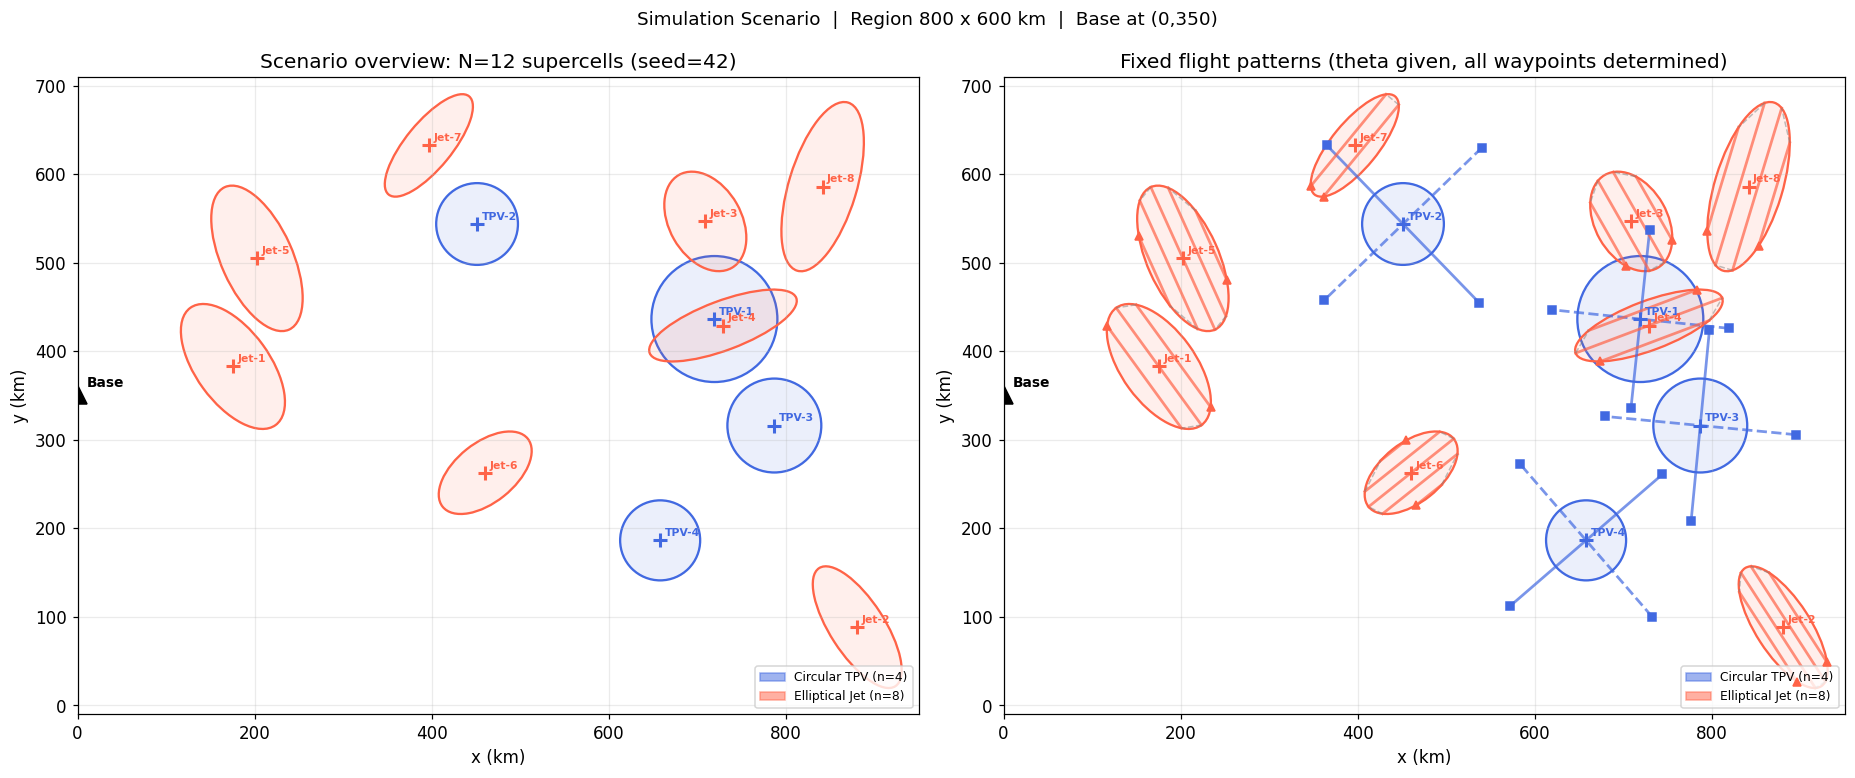

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

for ax_idx, ax in enumerate(axes):
    # Base airport
    ax.plot(*BASE, 'k^', ms=12, zorder=10, label='Base airport')
    ax.text(BASE[0]+10, BASE[1]+10, 'Base', fontsize=9, fontweight='bold')

    for i, cell in enumerate(scenario):
        col = 'royalblue' if isinstance(cell, CircularSupercell) else 'tomato'

        if isinstance(cell, CircularSupercell):
            ax.add_patch(plt.Circle(cell.center, cell.radius, color=col, alpha=0.10))
            ax.add_patch(plt.Circle(cell.center, cell.radius,
                                     fill=False, edgecolor=col, lw=1.5))
        else:
            ax.add_patch(Ellipse(cell.center, 2*cell.a, 2*cell.b,
                                  angle=np.degrees(cell.phi), color=col, alpha=0.10))
            ax.add_patch(Ellipse(cell.center, 2*cell.a, 2*cell.b,
                                  angle=np.degrees(cell.phi),
                                  fill=False, edgecolor=col, lw=1.5))

        ax.plot(*cell.center, '+', color=col, ms=9, mew=2, zorder=6)

        if ax_idx == 1:
            # Second panel: show fixed flight legs
            if isinstance(cell, CircularSupercell):
                for j, (ps, pe) in enumerate(cell.leg_endpoints()):
                    ax.plot([ps[0],pe[0]], [ps[1],pe[1]], color=col, lw=1.8,
                            ls='-' if j==0 else '--', alpha=0.7)
                for pt in cell.candidates():
                    ax.plot(*pt, 's', color=col, ms=5, zorder=7)
            else:
                for j, (ps, pe) in enumerate(cell.leg_endpoints()):
                    ax.plot([ps[0],pe[0]], [ps[1],pe[1]], color=col, lw=1.8, alpha=0.7)
                wpts = cell.boustrophedon_wpts()
                for k in range(len(wpts)-1):
                    if k%2==1:
                        ax.plot([wpts[k][0],wpts[k+1][0]],
                                [wpts[k][1],wpts[k+1][1]],
                                color='gray', lw=1.0, ls='--', alpha=0.5)
                for pt in cell.candidates():
                    ax.plot(*pt, '^', color=col, ms=5, zorder=7)

        # Label
        ax.text(cell.center[0]+5, cell.center[1]+5, cell.name,
                fontsize=7, color=col, fontweight='bold')

    ax.set_xlim(X_MIN-100, X_MAX+50)
    ax.set_ylim(Y_MIN-60,  Y_MAX+60)
    ax.set_aspect('equal')
    ax.set_xlabel('x (km)'); ax.set_ylabel('y (km)')
    ax.grid(True, alpha=0.25)

    circ_patch = mpatches.Patch(color='royalblue', alpha=0.5, label=f'Circular TPV (n={sum(isinstance(c,CircularSupercell) for c in scenario)})')
    ell_patch  = mpatches.Patch(color='tomato',    alpha=0.5, label=f'Elliptical Jet (n={sum(isinstance(c,EllipticalSupercell) for c in scenario)})')
    ax.legend(handles=[circ_patch, ell_patch], fontsize=8, loc='lower right')

axes[0].set_title(f'Scenario overview: N={N} supercells (seed={SEED})')
axes[1].set_title('Fixed flight patterns (theta given, all waypoints determined)')

plt.suptitle(f'Simulation Scenario  |  Region {X_MAX-X_MIN:.0f} x {Y_MAX-Y_MIN:.0f} km  |  Base at ({BASE[0]:.0f},{BASE[1]:.0f})',
             fontsize=12)
plt.tight_layout()
plt.savefig('figures/scenario_overview.png', bbox_inches='tight', dpi=120)
plt.show()


In [5]:
# ── Scenario statistics ──
int_dists = [c.internal_distance() for c in scenario]
weights   = [c.weight for c in scenario]

print("=== Scenario Statistics ===")
print(f"Total internal flight dist (if all visited): {sum(int_dists):.1f} km")
print(f"  Mean per cell: {np.mean(int_dists):.1f} km")
print(f"  Range: [{min(int_dists):.1f}, {max(int_dists):.1f}] km")
print()
print(f"Weight range: [{min(weights):.2f}, {max(weights):.2f}]  mean={np.mean(weights):.2f}")
print()

# Pairwise distance stats (centroid-to-centroid, rough estimate of inter-cell cost)
centers_arr = np.array([c.center for c in scenario])
dists = []
for i in range(N):
    for j in range(i+1, N):
        dists.append(np.linalg.norm(centers_arr[i] - centers_arr[j]))
print(f"Inter-cell centroid distances:")
print(f"  Mean: {np.mean(dists):.1f} km  |  Min: {min(dists):.1f} km  |  Max: {max(dists):.1f} km")
print()
print("=> Rough lower bound on total transit distance (min spanning path):")
print(f"   At least {min(dists)*(N-1):.0f} km if all cells were collinear and adjacent.")


=== Scenario Statistics ===
Total internal flight dist (if all visited): 6820.5 km
  Mean per cell: 568.4 km
  Range: [286.6, 786.5] km

Weight range: [0.85, 2.28]  mean=1.60

Inter-cell centroid distances:
  Mean: 376.8 km  |  Min: 12.1 km  |  Max: 795.7 km

=> Rough lower bound on total transit distance (min spanning path):
   At least 134 km if all cells were collinear and adjacent.


In [6]:
fname = f'data/scenario_N{N}_seed{SEED}.pkl'
save_obj = {
    'scenario': scenario,
    'N': N,
    'frac_circular': FRAC_CIRC,
    'seed': SEED,
    'base': BASE,
    'region': (X_MIN, X_MAX, Y_MIN, Y_MAX),
}
with open(fname, 'wb') as f:
    pickle.dump(save_obj, f)

print(f"Saved scenario to: {fname}")
print()
print("Load in other notebooks with:")
print("  import pickle")
print(f"  data = pickle.load(open('{fname}', 'rb'))")
print("  scenario = data['scenario']")
print("  BASE     = data['base']")


Saved scenario to: data/scenario_N12_seed42.pkl

Load in other notebooks with:
  import pickle
  data = pickle.load(open('data/scenario_N12_seed42.pkl', 'rb'))
  scenario = data['scenario']
  BASE     = data['base']
